In [1]:
import pricing_driven_service_allocation as pdsa

# URLS
PRIME_INSTANCE_URL = "http://localhost:3000/api/v1/"
# Paths
TOPOLOGIES_DIR = "synthetic-dataset/synthetic-topologies"
RESULTS_DIR = "results"
DEVICES_EUA_DATASET_PATH = "eua-dataset/edge-servers/site.csv"
CLIENTS_EUA_DATASET_PATH = "eua-dataset/users/users-aus.csv"
EXPERIMENT_CONFIGURATION_PATH = "experiments/experiment_test.yml"
# Scenario containers
topologies = {}
demands = {}
filters = {}
results = {}
# Configuration
SEED = 42
UNLIMITED_VALUE = 100000000
VENDORS_TO_CONSIDER = ["Telstra", "Optus", "Vodafone", "Telecom", "Macquarie"]
OFFER_CONFIGURATION = {
    "global": {
        "group_percentages": {1: 40, 2: 30, 3: 30},
        "group_ranges": {1: (0, 12.5), 2: (12.5, 50), 3: (50, 100)},
    },
    "attributes": {
        "available_ram_gb": {
            "min": 1,
            "max": 128,
            "default_price": 0.5,
            "price_by_provider_group": {
                "OPTUS": {1: 1, 2: 0.15, 3: 0.005},
                "TELSTRA": {1: 1.3, 2: 0.12, 3: 0.003},
                "VODAFONE": {1: 1.5, 2: 0.18, 3: 0.001},
                "MACQUARIE": {1: 0.2, 2: 0.17, 3: 0.008},
                "TELECOM": {1: 0.7, 2: 0.14, 3: 0.004},
            },
            "local_distribution": {1: [(70, 0, 25), (30, 25, 100)]},
        },
        "available_storage_gb": {
            "min": 1,
            "max": 2000,  # gigabytes; adjust if you want very large storage nodes
            "default_price": 0.2,
            "price_by_provider_group": {
                "OPTUS": {1: 0.90, 2: 0.25, 3: 0.08},
                "TELSTRA": {1: 1.10, 2: 0.30, 3: 0.10},
                "VODAFONE": {1: 1.25, 2: 0.35, 3: 0.05},
                "MACQUARIE": {1: 0.50, 2: 0.20, 3: 0.09},
                "TELECOM": {1: 0.85, 2: 0.28, 3: 0.07},
            },
            "local_distribution": {
                # Conserva tu intención: muchos dispositivos con poco almacenamiento y unos pocos con más
                1: [(70, 0, 2), (30, 2, 25)]
            },
        },
        "available_cpu_cores": {
            "min": 1,
            "max": 64,
            "default_price": 15,
        },
        # Unidades equivalentes, coherentes con gpu_equivalent_units en demanda
        "available_gpu_units": {
            "min": 0,
            "max": 8,
            "default_price": 120,
            "price_by_provider_group": {
                "TELSTRA": {2: 130, 3: 150},
                "OPTUS": {3: 140},
            },
            "local_distribution": {
                1: [(85, 0, 25), (15, 25, 50)],
                2: [(60, 0, 50), (40, 50, 100)],
                3: [(30, 0, 50), (70, 50, 100)],
            },
        },
        "available_tpu_units": {
            "min": 0,
            "max": 4,
            "default_price": 200,
            "price_by_provider_group": {
                "TELSTRA": {3: 240},
                "OPTUS": {2: 210},
            },
            "local_distribution": {
                1: [(90, 0, 25), (10, 25, 50)],
                2: [(70, 0, 50), (30, 50, 100)],
                3: [(40, 0, 50), (60, 50, 100)],
            },
        },
        # Opcional: si luego quieres que el algoritmo también restrinja por ancho de banda
        "available_network_in_mbps": {
            "min": 10,
            "max": 10000,
            "default_price": 0.01,
            "local_distribution": {
                1: [(80, 0, 20), (20, 20, 100)],
                2: [(60, 20, 60), (40, 60, 100)],
                3: [(20, 60, 100), (80, 80, 100)],
            },
        },
        "available_network_out_mbps": {
            "min": 10,
            "max": 10000,
            "default_price": 0.01,
            "local_distribution": {
                1: [(80, 0, 20), (20, 20, 100)],
                2: [(60, 20, 60), (40, 60, 100)],
                3: [(20, 60, 100), (80, 80, 100)],
            },
        },
    },
    "device_types_by_group": {
        1: {"CAMERA": 35, "SENSOR": 35, "NETWORK_NODE": 30},
        2: {"COMPUTER": 60, "NETWORK_NODE": 40},
        3: {"DATA_CENTER": 100},
    },
}
RESOURCES_TO_CONSIDER = [
    key for key in OFFER_CONFIGURATION["attributes"].keys() if "network" not in key
]

In [6]:
import yaml
import os

# Load the YAML file
with open(os.path.join(EXPERIMENT_CONFIGURATION_PATH), 'r') as file:
  config_data = yaml.safe_load(file)
  
for scenario_size in config_data['experiments'].keys():
    for scenario_id in config_data['experiments'][scenario_size].keys():
        topology_offer = config_data['experiments'][scenario_size][scenario_id]['offer']
        # Check that all providers in the topology offer are in the vendors to consider
        providers_in_offer = [p.lower() for p in topology_offer['providers'].keys()]
        vendors_lower = [v.lower() for v in VENDORS_TO_CONSIDER]

        if not all(provider in vendors_lower for provider in providers_in_offer):
          raise ValueError(f"Some providers in topology {scenario_size}/{scenario_id} offer are not in VENDORS_TO_CONSIDER."
                   f"Providers in offer: {providers_in_offer}, "
                   f"Vendors to consider: {vendors_lower}")

In [7]:
import os
import shutil

# Create all defined paths if they do not exist
paths_to_create = [
  TOPOLOGIES_DIR,
]

for path in paths_to_create:
  if path and not os.path.exists(path):
    os.makedirs(path, exist_ok=True)
    print(f"Created directory: {path}")
  elif path and os.path.exists(path):
    print(f"Directory already exists: {path}. Removing existing subfolders...")
    # Remove existing subfolders (including non-empty ones)
    for subfolder in os.listdir(path):
      subfolder_path = os.path.join(path, subfolder)
      if os.path.isdir(subfolder_path):
        shutil.rmtree(subfolder_path)
    print("Done!")
    

Created directory: synthetic-dataset/synthetic-topologies


# 2. Filter EUA dataset

In this step, we will filter the EUA dataset to include only devices from which we can infer the vendor, usually throug their description. This is crucial for our analysis as it allows us to categorize devices and simulate exclusion and interoperability relationships among providers.

In addition, we will enrich the dataset with synthetic resources, unit prices, and device types. This enrichment is based on the OFFER_CONFIGURATION defined at the beginning of the notebook.

In [8]:
# Load dataset
devices_df = pdsa.dataset.load_devices_dataframe(DEVICES_EUA_DATASET_PATH)
# Filter devices from which vendor can be inferred
devices_df = pdsa.dataset.filter_devices_by_vendors(devices_df, VENDORS_TO_CONSIDER)
# Assign resources to devices based on the offer configuration
devices_df = pdsa.dataset.assign_device_resources(devices_df, OFFER_CONFIGURATION, SEED)

devices_df.head()

,latitude,longitude,elevation,provider,global_group,device_type,available_ram_gb,unit_price_available_ram_gb,available_storage_gb,unit_price_available_storage_gb,available_cpu_cores,unit_price_available_cpu_cores,available_gpu_units,unit_price_available_gpu_units,available_tpu_units,unit_price_available_tpu_units,available_network_in_mbps,unit_price_available_network_in_mbps,available_network_out_mbps,unit_price_available_network_out_mbps
device_id,,,,,,,,,,,,,,,,,,,,
10000002,-28.777660,114.634260,NaN,OPTUS,1,SENSOR,5,1.000,5,0.90,4,15.0,0,120.0,0,200.0,25,0.01,983,0.01
100001,-38.248652,144.605442,23.0,TELSTRA,1,NETWORK_NODE,12,1.300,9,1.10,6,15.0,0,120.0,0,200.0,130,0.01,239,0.01
10000114,-31.901910,152.533540,NaN,OPTUS,3,DATA_CENTER,95,0.005,1818,0.08,39,15.0,7,140.0,3,200.0,9296,0.01,9484,0.01
100002,-37.728550,145.222007,116.0,OPTUS,2,NETWORK_NODE,61,0.150,394,0.25,29,15.0,1,120.0,0,210.0,4437,0.01,2391,0.01
10000215,-32.981570,121.644400,NaN,TELSTRA,2,NETWORK_NODE,22,0.120,949,0.30,11,15.0,1,130.0,1,200.0,2270,0.01,2359,0.01


# 3. Topology Generation

In [9]:
from tqdm import tqdm

for scenario_size in config_data['experiments'].keys():
  print(f"Generating topologies for scenario size: {scenario_size}")
  for scenario_id in config_data['experiments'][scenario_size].keys():
    for i in tqdm(range(100), desc=f"Generating topologies for {scenario_size}_{scenario_id}"):
      topology_offer = config_data['experiments'][scenario_size][scenario_id]['offer']
      _, topology_id = pdsa.generators.topology(
                        lat = topology_offer['zone']['lat'],
                        long = topology_offer['zone']['long'],
                        center_elevation = topology_offer['zone'].get('elevation', 0),
                        rad=topology_offer['zone']['radius'],
                        devices_df=devices_df,
                        topologies_result_dir=TOPOLOGIES_DIR,
                        resources_to_consider=RESOURCES_TO_CONSIDER,
                        number_of_providers=len(topology_offer["providers"]),
                        allowed_groups=[1, 2, 3],
                        number_of_devices=topology_offer['max_devices'],
                        options={
                          # "seed": SEED,
                          "logs": False
                        }
                    )
      topologies[f"{scenario_size}_{scenario_id}_{i}"] = topology_id
        
print("---- Topologies generated ----\n")
for key, value in topologies.items():
  print(f"{key}: {value}")

Generating topologies for scenario size: small


Generating topologies for small_devices_lidar_50: 100%|██████████| 100/100 [00:07<00:00, 12.90it/s]
Generating topologies for small_devices_lidar_100: 100%|██████████| 100/100 [00:07<00:00, 12.89it/s]
Generating topologies for small_devices_lidar_150: 100%|██████████| 100/100 [00:07<00:00, 12.89it/s]
Generating topologies for small_devices_lidar_200: 100%|██████████| 100/100 [00:07<00:00, 12.80it/s]
Generating topologies for small_clients_lidar_50: 100%|██████████| 100/100 [00:07<00:00, 12.78it/s]
Generating topologies for small_clients_lidar_100: 100%|██████████| 100/100 [00:07<00:00, 12.87it/s]
Generating topologies for small_clients_lidar_150: 100%|██████████| 100/100 [00:07<00:00, 12.76it/s]
Generating topologies for small_clients_lidar_200: 100%|██████████| 100/100 [00:07<00:00, 12.78it/s]
Generating topologies for small_clients_cctv_80: 100%|██████████| 100/100 [00:07<00:00, 12.62it/s]


Generating topologies for scenario size: medium


Generating topologies for medium_clients_vr_800: 100%|██████████| 100/100 [00:07<00:00, 12.63it/s]
Generating topologies for medium_devices_robot_50: 100%|██████████| 100/100 [00:07<00:00, 13.04it/s]
Generating topologies for medium_devices_robot_100: 100%|██████████| 100/100 [00:07<00:00, 12.74it/s]
Generating topologies for medium_devices_robot_150: 100%|██████████| 100/100 [00:07<00:00, 12.52it/s]
Generating topologies for medium_devices_robot_200: 100%|██████████| 100/100 [00:08<00:00, 12.47it/s]
Generating topologies for medium_clients_robot_75: 100%|██████████| 100/100 [00:07<00:00, 13.01it/s]
Generating topologies for medium_clients_robot_150: 100%|██████████| 100/100 [00:07<00:00, 12.94it/s]
Generating topologies for medium_clients_robot_225: 100%|██████████| 100/100 [00:07<00:00, 12.95it/s]
Generating topologies for medium_clients_robot_300: 100%|██████████| 100/100 [00:07<00:00, 12.93it/s]
Generating topologies for medium_devices_lidar_50: 100%|██████████| 100/100 [00:07<00:0

Generating topologies for scenario size: large


Generating topologies for large_clients_vr_8000: 100%|██████████| 100/100 [00:07<00:00, 12.96it/s]
Generating topologies for large_devices_robot_300: 100%|██████████| 100/100 [00:08<00:00, 12.09it/s]
Generating topologies for large_devices_robot_400: 100%|██████████| 100/100 [00:08<00:00, 11.74it/s]
Generating topologies for large_devices_robot_450: 100%|██████████| 100/100 [00:08<00:00, 11.58it/s]
Generating topologies for large_devices_robot_500: 100%|██████████| 100/100 [00:08<00:00, 11.43it/s]
Generating topologies for large_clients_robot_250: 100%|██████████| 100/100 [00:07<00:00, 12.97it/s]
Generating topologies for large_clients_robot_500: 100%|██████████| 100/100 [00:07<00:00, 12.97it/s]
Generating topologies for large_clients_robot_750: 100%|██████████| 100/100 [00:07<00:00, 13.00it/s]
Generating topologies for large_clients_robot_1000: 100%|██████████| 100/100 [00:07<00:00, 12.99it/s]
Generating topologies for large_devices_lidar_300: 100%|██████████| 100/100 [00:07<00:00, 12

---- Topologies generated ----

small_devices_vr_5_0: 9baad6e2-c21e-4362-bb07-c622f79fb5cf
small_devices_vr_5_1: d0ef8636-3b40-4b27-b758-a535c11b0274
small_devices_vr_5_2: a993e574-482a-45dd-9fc4-3f5038214b5e
small_devices_vr_5_3: 45bf98e0-14b6-47ee-8ca9-854651e9922a
small_devices_vr_5_4: e3a7b086-b3bf-4cd8-b6e8-b4bbd15b2d61
small_devices_vr_5_5: 495b94a2-efaf-4442-91f8-515224532196
small_devices_vr_5_6: 8947dea5-266b-4b79-96c8-2132ac9d441b
small_devices_vr_5_7: 1a289916-2824-48c5-bb94-c6254749ea2f
small_devices_vr_5_8: 6d1af783-cdae-460b-9788-14a752a89d4d
small_devices_vr_5_9: 32dd52c3-6ee7-4a59-9be8-467dd6f6c5c1
small_devices_vr_5_10: 1251e2b9-a6d0-49eb-b973-5a03f9a46be1
small_devices_vr_5_11: 9abdd12d-dca6-4aac-8a34-38f79a49a6a8
small_devices_vr_5_12: 74bf8757-5b5a-40d9-8583-59f6d598ad9b
small_devices_vr_5_13: a95861e8-01c0-4c8d-b0dd-95ac5b711dfc
small_devices_vr_5_14: 7e56c78d-3b50-4489-b70f-656997adf0e9
small_devices_vr_5_15: 8b94e4e1-2cbe-477e-81ca-7f9fcc957ecf
small_devices_vr_5

# 4. Problem instance generation

In [10]:
import os

if not os.path.exists("./iPricing/model"):
    os.makedirs("./iPricing/model")

!protoc --python_out=./iPricing/model ./iPricing/iPricing.proto
!mv ./iPricing/model/iPricing/iPricing_pb2.py ./iPricing/model/iPricing_pb2.py
!rm -rf ./iPricing/model/iPricing

In [11]:
import pandas as pd
from pricing_driven_service_allocation.generators.client_demand import AppType

app_mapping = {
  "vr": AppType.AR_VR,
  "cctv": AppType.VIDEO_PRIVACY,
  "lidar": AppType.LIDAR,
  "robot": AppType.ROBOT_IOT
}

In [12]:
from tqdm import tqdm
from iPricing.model.iPricing_pb2 import Pricing

for id, topology_id in tqdm(topologies.items(), desc="Generating instances"):
  scenario_size, experiment_type, app, amount, test_id = id.split("_")
  topology_demand = config_data['experiments'][scenario_size][f"{experiment_type}_{app}_{amount}"]['demand']
  topology_request = config_data['experiments'][scenario_size][f"{experiment_type}_{app}_{amount}"]['request']
  
  users_demand = pdsa.generators.client_demand.calculate_resources(topology_demand['n_clients'], 
                                                                   app_mapping[app], 
                                                                   concurrency=topology_demand['concurrency'], 
                                                                   requests_per_second_per_active_client=topology_demand['requests_per_second_per_active_client'], 
                                                                   requests_per_second_std=topology_demand['requests_per_second_std'], 
                                                                   resources_to_consider=RESOURCES_TO_CONSIDER, 
                                                                  #  random_state=SEED
                                                                  )
  
  request = pdsa.generators.request(
      topology_demand=topology_demand,
      topology_request=topology_request,
      users_demand=users_demand,
      resources_to_consider=RESOURCES_TO_CONSIDER,
  )
  
  pricing_path = pdsa.generators.pricing_from_topology(
            topology_id=topology_id,
            topologies_result_dir=TOPOLOGIES_DIR,
            resources_to_consider=RESOURCES_TO_CONSIDER,
            compatible_provider_groups=pdsa.generators.compatible_provider_groups_from_offer(topology_offer),
            options={"logs": False}
          )
  
  pricing_obj = pdsa.utils.yaml_to_pricing_proto(
      os.path.join(TOPOLOGIES_DIR, topology_id, "pricing.yml"), 
      Pricing
  )
  
  problem_instance_pricing, filter_criteria = pdsa.generators.problem_instance(
                                                  instance_pricing=pricing_obj,
                                                  request=request,
                                                  topologies_result_dir=TOPOLOGIES_DIR,
                                                  unlimited_value=UNLIMITED_VALUE
                                              )
  
  pdsa.utils.pricing_proto_to_yaml(
    problem_instance_pricing, 
    os.path.join(TOPOLOGIES_DIR, topology_id, "problem_instance_pricing.yml"),
    options={"logs": False}
  )
  
  filters[id] = filter_criteria
  

Generating instances: 100%|██████████| 9600/9600 [1:48:14<00:00,  1.48it/s]  


# 5. Pricing Optimization

In [14]:
import time
import os
from tqdm import tqdm

if os.path.exists(os.path.join(RESULTS_DIR, "results.csv")):
    print(f"Results directory '{RESULTS_DIR}' already exists. Removing existing results...")
    shutil.rmtree(RESULTS_DIR)
    print("Done!")

for id in tqdm(list(topologies.keys()), desc="Optimizing topologies"):
  instance_path = os.path.join(TOPOLOGIES_DIR, topologies[id], "problem_instance_pricing.yml")
  
  filter = filters[id]
  
  start = time.time()
  result = pdsa.optimize(PRIME_INSTANCE_URL, instance_path, filter)
  elapsed_time = time.time() - start
  
  results[id] = {
    "result": result,
    "filter": filter,
    "time": elapsed_time
  }
  
  pdsa.dataset.save_results_to_csv(
    result_obj=results[id],
    scenario_id=id,
    RESULTS_DIR=RESULTS_DIR
  )
  
  

Optimizing topologies: 100%|██████████| 9600/9600 [9:21:32<00:00,  3.51s/it]   


In [ ]:
print(results["small_devices_robot_5"])
print(results["large_devices_vr_300"])

{'result': {'jobId': 'job-c53c4fca-4aa6-4d68-91a4-7032bbc51e4c', 'status': 'COMPLETED', 'submittedAt': '2026-02-23T14:57:08.247Z', 'startedAt': '2026-02-23T14:57:08.247Z', 'completedAt': '2026-02-23T14:57:08.325Z', 'result': {'error': 'No solution found for the given filters.'}}, 'filter': {'maxPrice': 1000, 'maxSubscriptionSize': 3, 'usageLimits': {'available_ram_gb': 1, 'available_storage_gb': 16, 'available_cpu_cores': 1, 'available_gpu_units': 0, 'available_tpu_units': 0, 'distance': 99999500}, 'features': ['SENSOR', 'COMPUTER', 'NETWORK_NODE']}, 'time': 0.10999011993408203}
{'result': {'jobId': 'job-5171cc45-21ed-47ae-9d06-28cf2bfdabd6', 'status': 'COMPLETED', 'submittedAt': '2026-02-23T14:57:24.362Z', 'startedAt': '2026-02-23T14:57:24.362Z', 'completedAt': '2026-02-23T14:57:33.952Z', 'result': {'optimal': {'subscription': {'addOns': ['VODAFONE_303723', 'TELSTRA_304064', 'TELSTRA_301275', 'TELSTRA_9015666'], 'features': ['CAMERA', 'NETWORK_NODE', 'DATA_CENTER', 'SENSOR'], 'usageLi

# 6. Display results

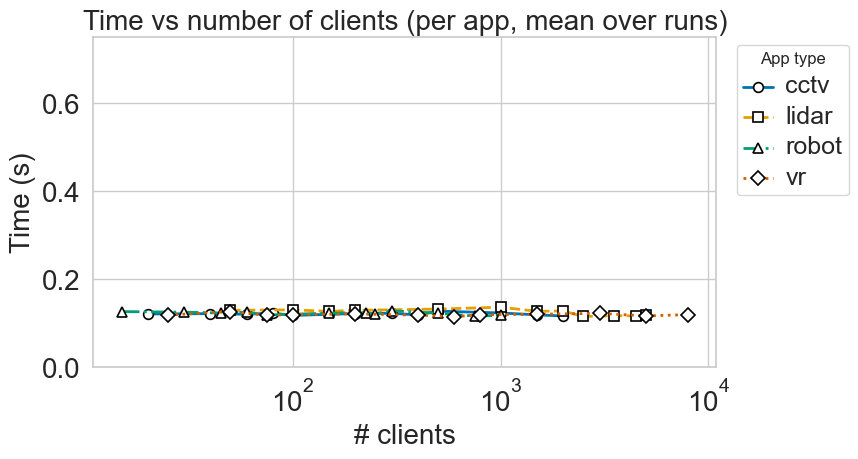

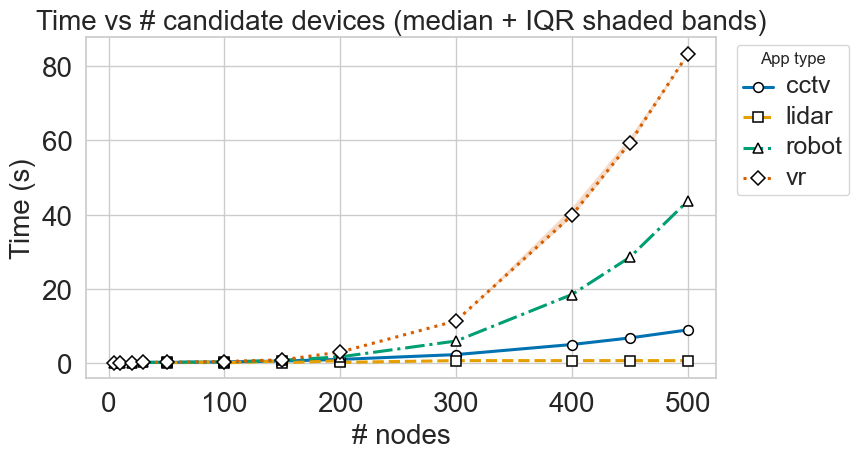

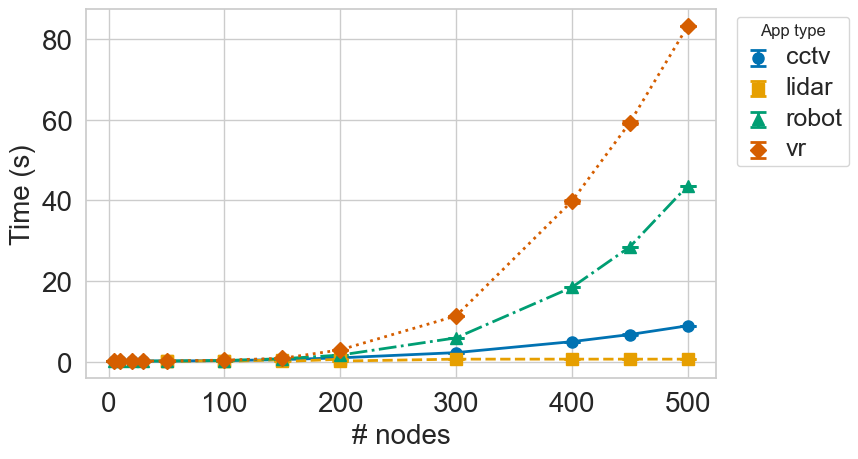

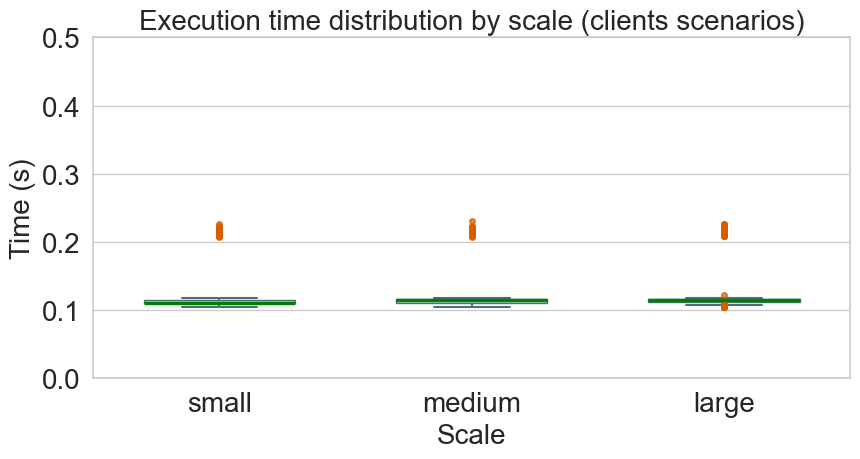

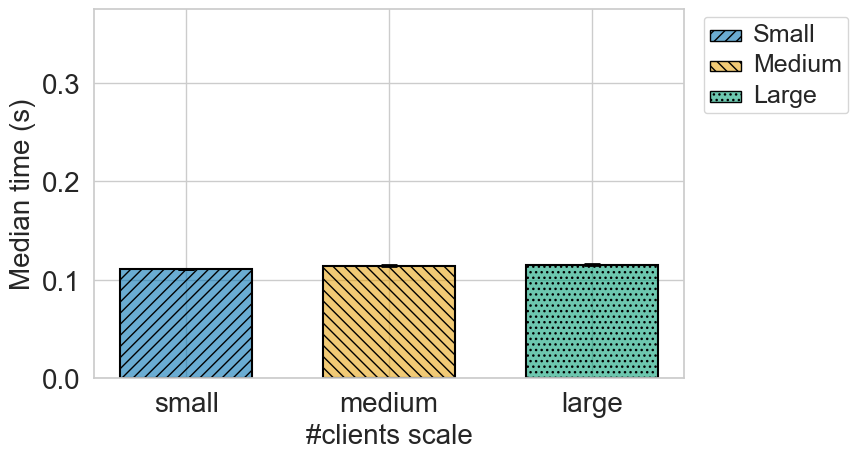

Saved figures in: results/figures


In [10]:
# 6. Display and save result figures (clients/devices progression)
import pandas as pd
import os
import yaml
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style='whitegrid')
# Plot style / font sizes
FONT_SIZE = 20
TITLE_SIZE = 20
LEGEND_SIZE = 18
TICK_SIZE = 20
plt.rcParams.update({'font.size': FONT_SIZE})

RESULTS_CSV = os.path.join(RESULTS_DIR, 'results.csv')
df = pd.read_csv(RESULTS_CSV)

# Ensure numeric time and drop invalid rows
df['time_seconds'] = pd.to_numeric(df['time_seconds'], errors='coerce')
df = df.dropna(subset=['time_seconds', 'scenario_id']).copy()

# Build scenario base by removing trailing run index (_0.._99)
# Expected format now:
# {small|medium|large}_{clients|devices}_{vr|robot|cctv|lidar}_{num}_{run_idx}
df['scenario_id'] = df['scenario_id'].astype(str)
df['scenario_base'] = df['scenario_id'].str.replace(r'_[0-9]+$', '', regex=True)

# Parse scenario_base: size_kind_app_amount
base_parts = df['scenario_base'].str.split('_')
df['size'] = base_parts.str[0].fillna('')
df['kind'] = base_parts.str[1].fillna('')
df['app'] = base_parts.str[2].fillna('')
df['amount'] = pd.to_numeric(base_parts.str[3], errors='coerce')

# Aggregate for clients plot (mean kept as in original figure 1)
df_plot = (
    df.groupby(['scenario_base', 'size', 'kind', 'app', 'amount'], as_index=False)['time_seconds']
      .mean()
)

# Aggregates for devices plots (median + distribution/error information)
df_devices_raw = df[df['kind'].str.contains('devices', na=False)].copy()
df_devices_stats = (
    df_devices_raw.groupby(['scenario_base', 'size', 'kind', 'app', 'amount'], as_index=False)
    .agg(
        time_median=('time_seconds', 'median'),
        time_q1=('time_seconds', lambda x: x.quantile(0.25)),
        time_q3=('time_seconds', lambda x: x.quantile(0.75)),
        time_mean=('time_seconds', 'mean'),
        time_std=('time_seconds', 'std'),
        n=('time_seconds', 'count')
    )
)

# 95% CI around median (normal-approx): 1.57 * IQR / sqrt(n)
df_devices_stats['iqr'] = df_devices_stats['time_q3'] - df_devices_stats['time_q1']
df_devices_stats['ci95_median'] = 1.57 * df_devices_stats['iqr'].fillna(0.0) / np.sqrt(df_devices_stats['n'].clip(lower=1))

# Dual encoding for color + B/W readability
linestyles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
# Okabe-Ito (colorblind-friendly) palette
palette = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9', '#F0E442', '#000000']


def style_for_label(label, labels):
    ordered = sorted(labels)
    idx = ordered.index(label)
    return {
        'linestyle': linestyles[idx % len(linestyles)],
        'marker': markers[idx % len(markers)],
        'color': palette[idx % len(palette)]
    }


# Figures directory
figures_dir = os.path.join(RESULTS_DIR, 'figures')
os.makedirs(figures_dir, exist_ok=True)

# 1) Clients: for ids containing 'clients' -> x = amount (clients), y = mean(time_seconds)
df_clients = df_plot[df_plot['kind'].str.contains('clients', na=False)].copy()
plt.figure(figsize=(9, 5))
client_apps = sorted(df_clients['app'].dropna().unique())
for app, g in df_clients.groupby('app'):
    g_sorted = g.sort_values('amount')
    style = style_for_label(app, client_apps)
    plt.plot(
        g_sorted['amount'],
        g_sorted['time_seconds'],
        color=style['color'],
        linestyle=style['linestyle'],
        marker=style['marker'],
        markersize=7,
        linewidth=2,
        markerfacecolor='white',
        markeredgecolor='black',
        markeredgewidth=1.2,
        label=app
    )

# Configure x ticks: show up to 8 ticks (log or linear depending on scale)
ax = plt.gca()
amounts = df_clients['amount'].dropna().unique() if not df_clients.empty else []
if len(amounts) > 0:
    amin = float(amounts.min())
    amax = float(amounts.max())
    use_log = (amin > 0) and (amax / max(1.0, amin) > 20)
    if use_log:
        ticks = np.unique(np.round(np.logspace(np.log10(max(1.0, amin)), np.log10(amax), num=8)).astype(int))
    else:
        ticks = np.linspace(amin, amax, num=min(8, max(1, len(amounts))))
    try:
        ax.set_xticks(ticks)
    except Exception:
        pass
    ax.tick_params(labelsize=TICK_SIZE)

plt.xscale('log') if (df_clients['amount'] > 0).any() and df_clients['amount'].max() / df_clients['amount'].min() > 20 else None
plt.xlabel('# clients', fontsize=FONT_SIZE)
plt.ylabel('Time (s)', fontsize=FONT_SIZE)
plt.title('Time vs number of clients (per app, mean over runs)', fontsize=TITLE_SIZE)
plt.ylim(0, 0.75)
leg = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, title='App type')
if leg is not None:
    plt.setp(leg.get_texts(), fontsize=LEGEND_SIZE)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'time_vs_n_clients_by_app.png'), dpi=300)
plt.show()

# 2A) Devices: median with interquartile shaded bands (Q1-Q3)
plt.figure(figsize=(9, 5))
device_apps = sorted(df_devices_stats['app'].dropna().unique())
for app, g in df_devices_stats.groupby('app'):
    g_sorted = g.sort_values('amount')
    style = style_for_label(app, device_apps)

    plt.plot(
        g_sorted['amount'],
        g_sorted['time_median'],
        color=style['color'],
        linestyle=style['linestyle'],
        marker=style['marker'],
        markersize=7,
        linewidth=2.2,
        markerfacecolor='white',
        markeredgecolor='black',
        markeredgewidth=1.1,
        label=app
    )
    plt.fill_between(
        g_sorted['amount'],
        g_sorted['time_q1'],
        g_sorted['time_q3'],
        color=style['color'],
        alpha=0.22,
        linewidth=0
    )

ax = plt.gca()
ax.tick_params(labelsize=TICK_SIZE)
plt.xlabel('# nodes', fontsize=FONT_SIZE)
plt.ylabel('Time (s)', fontsize=FONT_SIZE)
plt.title('Time vs # candidate devices (median + IQR shaded bands)', fontsize=TITLE_SIZE)
leg = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, title='App type')
if leg is not None:
    plt.setp(leg.get_texts(), fontsize=LEGEND_SIZE)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'time_vs_num_devices_by_app_iqr_bands.png'), dpi=300)
plt.show()

# 2B) Devices: median with point-wise error bars (95% CI around median)
plt.figure(figsize=(9, 5))
for app, g in df_devices_stats.groupby('app'):
    g_sorted = g.sort_values('amount')
    style = style_for_label(app, device_apps)

    # Trend line
    plt.plot(
        g_sorted['amount'],
        g_sorted['time_median'],
        color=style['color'],
        linestyle=style['linestyle'],
        linewidth=2.0
    )

    # Error bars at each point
    plt.errorbar(
        g_sorted['amount'],
        g_sorted['time_median'],
        yerr=g_sorted['ci95_median'],
        color=style['color'],
        fmt=style['marker'],
        markersize=8,
        markerfacecolor=style['color'],
        markeredgecolor=style['color'],
        elinewidth=2.0,
        capsize=6,
        capthick=2.0,
        label=app
    )

ax = plt.gca()
ax.tick_params(labelsize=TICK_SIZE)
plt.xlabel('# nodes', fontsize=FONT_SIZE)
plt.ylabel('Time (s)', fontsize=FONT_SIZE)
# plt.title('Time vs # candidate devices (median + error bars)', fontsize=TITLE_SIZE)
leg = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, title='App type')
if leg is not None:
    plt.setp(leg.get_texts(), fontsize=LEGEND_SIZE)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'time_vs_num_devices_by_app_errorbars.png'), dpi=300)
plt.show()

# 3) Boxplot by scale (small / medium / large) using ONLY clients scenarios
size_order = ['small', 'medium', 'large']
df_clients_raw = df[df['kind'].str.contains('clients', na=False)].copy()
df_box = df_clients_raw[df_clients_raw['size'].isin(size_order)].copy()
df_box['size'] = pd.Categorical(df_box['size'], categories=size_order, ordered=True)

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_box,
    x='size',
    y='time_seconds',
    order=size_order,
    width=0.6,
    boxprops={'facecolor': '#BFD7EA', 'edgecolor': '#4F6D7A'},
    whiskerprops={'color': '#4F6D7A', 'linewidth': 1.5},
    capprops={'color': '#4F6D7A', 'linewidth': 1.5},
    flierprops={
        'marker': 'o',
        'markersize': 4,
        'markerfacecolor': '#D55E00',
        'markeredgecolor': '#D55E00',
        'alpha': 0.75
    },
    medianprops={'color': 'green', 'linewidth': 2.5}
)

ax = plt.gca()
ax.tick_params(labelsize=TICK_SIZE)
plt.xlabel('Scale', fontsize=FONT_SIZE)
plt.ylabel('Time (s)', fontsize=FONT_SIZE)
plt.title('Execution time distribution by scale (clients scenarios)', fontsize=TITLE_SIZE)
plt.ylim(0, 0.5)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'time_boxplot_by_scale_clients.png'), dpi=300)
plt.show()

# 4) Bar plot: median time by scale (clients) + error bars, readable in B/W
# Colors from Okabe-Ito palette (colorblind-friendly); hatches added for B/W printing
df_scale_stats = (
    df_clients_raw[df_clients_raw['size'].isin(size_order)]
    .groupby('size', as_index=False)
    .agg(
        time_median=('time_seconds', 'median'),
        time_q1=('time_seconds', lambda x: x.quantile(0.25)),
        time_q3=('time_seconds', lambda x: x.quantile(0.75)),
        n=('time_seconds', 'count')
    )
)
df_scale_stats['size'] = pd.Categorical(df_scale_stats['size'], categories=size_order, ordered=True)
df_scale_stats = df_scale_stats.sort_values('size')
df_scale_stats['iqr'] = df_scale_stats['time_q3'] - df_scale_stats['time_q1']
df_scale_stats['ci95_median'] = 1.57 * df_scale_stats['iqr'].fillna(0.0) / np.sqrt(df_scale_stats['n'].clip(lower=1))

plt.figure(figsize=(9, 5))
x_pos = np.arange(len(df_scale_stats))
# Okabe-Ito colors: blue, orange, green
bar_colors = ["#0071B295", "#E69D008A", "#009E7492"]
hatches = ['///', '\\\\\\', '...']
bars = plt.bar(
    x_pos,
    df_scale_stats['time_median'],
    color=bar_colors,
    edgecolor='black',
    linewidth=1.5,
    width=0.65
)
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

plt.errorbar(
    x_pos,
    df_scale_stats['time_median'],
    yerr=df_scale_stats['ci95_median'],
    fmt='none',
    ecolor='black',
    elinewidth=2.0,
    capsize=6,
    capthick=2.0
)

ax = plt.gca()
ax.tick_params(labelsize=TICK_SIZE)
    
plt.xticks(x_pos, df_scale_stats['size'].astype(str))
plt.xlabel('#clients scale', fontsize=FONT_SIZE)
plt.ylabel('Median time (s)', fontsize=FONT_SIZE)
# plt.title('Median execution time by scale (clients) + error bars', fontsize=TITLE_SIZE)

# visual headroom factor (paper-friendly)
upper_lim = 0.3 * 1.25

plt.ylim(0, upper_lim)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor=bar_colors[0], edgecolor='black',
          hatch=hatches[0], label='Small'),
    Patch(facecolor=bar_colors[1], edgecolor='black',
          hatch=hatches[1], label='Medium'),
    Patch(facecolor=bar_colors[2], edgecolor='black',
          hatch=hatches[2], label='Large'),
]

leg = plt.legend(
    handles=legend_elements,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True
)

if leg is not None:
    plt.setp(leg.get_texts(), fontsize=LEGEND_SIZE)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'time_median_bar_by_scale_clients.png'), dpi=300)
plt.show()

print('Saved figures in:', figures_dir)


# Analytical analysis of the results

In [7]:
import pandas as pd
import numpy as np
import os

from scipy.stats import shapiro

RESULTS_CSV = os.path.join(RESULTS_DIR, "results.csv")

df = pd.read_csv(RESULTS_CSV)

# ---------- preprocessing ----------
df["time_seconds"] = pd.to_numeric(df["time_seconds"], errors="coerce")
df = df.dropna(subset=["time_seconds", "scenario_id"]).copy()

df["scenario_id"] = df["scenario_id"].astype(str)
df["scenario_base"] = df["scenario_id"].str.replace(r"_[0-9]+$", "", regex=True)


# ---------- per-scenario analysis ----------
rows = []

for scen, g in df.groupby("scenario_base"):

    times = g["time_seconds"].values
    n = len(times)

    mean = np.mean(times)
    median = np.median(times)

    std = np.std(times, ddof=1) if n > 1 else 0.0
    cv = std / mean if mean > 0 else np.nan

    q1 = np.percentile(times, 25)
    q3 = np.percentile(times, 75)
    iqr = q3 - q1

    ci95_median = 1.57 * iqr / np.sqrt(max(n, 1))
    rel_ci = ci95_median / median if median > 0 else np.nan

    lower = median - 1.5 * iqr
    upper = median + 1.5 * iqr
    outliers = np.sum((times < lower) | (times > upper))
    outlier_ratio = outliers / n if n > 0 else 0.0

    if 3 <= n <= 5000:
        _, p_norm = shapiro(times)
    else:
        p_norm = np.nan

    rows.append([
        scen,
        n,
        mean,
        median,
        std,
        cv,
        rel_ci,
        outlier_ratio,
        p_norm
    ])

stats_df = pd.DataFrame(
    rows,
    columns=[
        "scenario",
        "runs",
        "mean",
        "median",
        "std",
        "cv",
        "relative_ci_median",
        "outlier_ratio",
        "shapiro_pvalue"
    ]
)

stats_df = stats_df.sort_values("cv")

print("\n=== INTRA-SCENARIO STATISTICS ===\n")
print(stats_df.to_string(index=False))


# ---------- global indicators ----------
total = len(stats_df)

non_normal = np.sum(stats_df["shapiro_pvalue"] <= 0.05)
high_outliers = np.sum(stats_df["outlier_ratio"] > 0.10)
ci_large = np.sum(stats_df["relative_ci_median"] > 0.05)

print("\n=== GLOBAL ROBUSTNESS INDICATORS ===\n")
print(f"Total scenarios analysed                 : {total}")
print(f"Scenarios rejecting normality            : {non_normal} ({non_normal/total:.2%})")
print(f"Scenarios with >10% outliers             : {high_outliers} ({high_outliers/total:.2%})")
print(f"Scenarios with relative CI >5%           : {ci_large} ({ci_large/total:.2%})")


# ---------- methodological recommendation ----------
print("\n=== RECOMMENDED CENTRAL TENDENCY ESTIMATOR ===\n")

if non_normal / total > 0.5 or high_outliers / total > 0.2:
    print("Recommendation: USE MEDIAN")
    print("Rationale: runtime distributions are frequently non-normal and/or exhibit heavy-tailed behaviour.")
    print("Median provides a robust estimator of execution time.")
else:
    print("Recommendation: MEAN acceptable")
    print("Rationale: distributions are sufficiently symmetric and stable.")


=== INTRA-SCENARIO STATISTICS ===

                 scenario  runs      mean    median      std       cv  relative_ci_median  outlier_ratio  shapiro_pvalue
  large_devices_robot_450   100 28.501158 28.500724 0.102622 0.003601            0.000653           0.08    2.679902e-01
     large_devices_vr_500   100 83.298510 83.216528 0.305167 0.003664            0.000781           0.07    6.416067e-05
  large_devices_robot_500   100 43.665905 43.650553 0.190407 0.004361            0.000813           0.04    1.230494e-06
  large_devices_robot_400   100 18.478344 18.479172 0.107304 0.005807            0.001123           0.03    1.061293e-03
   large_devices_cctv_400   100  5.025913  5.021432 0.033461 0.006658            0.001041           0.14    3.837956e-05
     large_devices_vr_300   100 11.416235 11.396082 0.087145 0.007633            0.001476           0.08    2.085199e-05
   large_devices_cctv_500   100  8.958277  8.954088 0.068531 0.007650            0.001303           0.11    7.138698e

# Debug helpers

In [ ]:
pricing_path = os.path.join(TOPOLOGIES_DIR, topologies["large_devices_vr_300"], "problem_instance_pricing.yml")

print(f"Pricing path: {pricing_path}")

pricing = pdsa.utils.yaml_to_pricing_proto(pricing_path, Pricing)

pdsa.utils.find_identical_addons(pricing)



Pricing path: synthetic-dataset/synthetic-topologies/3683d0ab-61df-469d-bff0-50fb60b7a31a/problem_instance_pricing.yml


[]